# PatchCraft(Algorithm, code)

# literature review

The rapid development of AI image generation has made it increasingly difficult for people to distinguish real images from synthetic ones. This issue is important not only because it may mislead users on social media, but also because it can be exploited for fraud, crime, and political manipulation. In this project, we implement an algorithm for detecting AI-generated fake images and analyze why it works and what kinds of features the neural network learns.

Our work is mainly based on three papers. First, Zhong et al.’s PatchCraft proposes a more universal fake-image detector by combining patch-based processing with fingerprint-based features. Second, Fridrich and Kodovský’s work on Rich Models for Steganalysis introduces SRM filters, which highlight subtle residual and high-frequency patterns and are widely used as fingerprint extractors. Third, Wang et al.’s CNN-Generated Images Are Surprisingly Easy to Spot… for Now shows that real and AI-generated images contain detectable differences and that a more universal detector is possible; their CNNSpot dataset is also an important benchmark for this task.

Based on these works, we implemented the PatchCraft pipeline as closely as possible. In addition, we trained and compared three models: an image-only classifier, a fingerprint-only classifier, and a hybrid classifier that combines both image and fingerprint features. This allows us to study not only performance differences, but also the role of fingerprints in universal fake-image detection.

**This section contains the implementation of our algorithm. For a more detailed analysis of how each component and feature works, please refer to feature_analysis.ipynb.

## Setup

In [1]:
! pip install torchvision matplotlib tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from PIL import Image
import os
import time
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
import random
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Helper Functions

### Smash

In [3]:
# Splits each image into overlapping patches, scores their visual diversity,
# and returns the most information-rich and least informative patch sets.
def smash(img, patch_size: int = 32, num_patches: int = 192, diversity_threshold: float = 0.33) -> tuple[torch.Tensor, torch.Tensor]:

    if isinstance(img, Image.Image):
        to_tensor = T.ToTensor()
        img_tensor = to_tensor(img).unsqueeze(0).to(device)
    else:
        img_tensor = img.to(device)

    B, C, H, W = img_tensor.shape

    unfold = F.unfold(img_tensor, kernel_size=patch_size, stride=patch_size//2)
    patches = unfold.view(B, C, patch_size, patch_size, -1).permute(0, 4, 1, 2, 3)

    if patches.shape[1] > num_patches:
        # Generate a separate random permutation per image so each image gets
        # its own independently-sampled patch subset, not a shared one.
        patches = torch.stack([
            patches[b, torch.randperm(patches.shape[1], device=device)[:num_patches]]
            for b in range(B)
        ])

    d1 = torch.abs(patches[:, :, :, 1:, :] - patches[:, :, :, :-1, :]).sum(dim=[2, 3, 4])
    d2 = torch.abs(patches[:, :, :, :, 1:] - patches[:, :, :, :, :-1]).sum(dim=[2, 3, 4])
    d3 = torch.abs(patches[:, :, :, 1:, 1:] - patches[:, :, :, :-1, :-1]).sum(dim=[2, 3, 4])
    d4 = torch.abs(patches[:, :, :, 1:, :-1] - patches[:, :, :, :-1, 1:]).sum(dim=[2, 3, 4])
    diversity_scores = (d1 + d2 + d3 + d4) / 4.0

    rich_list = []
    poor_list = []
    num_select = int(num_patches * diversity_threshold)
    num_select += 1 if num_select % 2 == 1 else 0

    for b in range(B):
        _, sorted_idx = torch.sort(diversity_scores[b], descending=True)
        rich_list.append(patches[b, sorted_idx[:num_select]])
        poor_list.append(patches[b, sorted_idx[-num_select:]])

    rich_patches = torch.cat(rich_list, dim=0)
    poor_patches = torch.cat(poor_list, dim=0)

    return rich_patches, poor_patches


### Reconstruct

In [5]:
# Reassembles selected patches into a compact grid image so they can be
# processed efficiently by the SRM and fingerprint extraction modules.
def reconstruct(patches: torch.Tensor, patches_per_image: int = 64) -> torch.Tensor:
    """Reconstructs batched collages. patches shape: [N, 3, P, P] where N = B * patches_per_image"""
    total = patches.shape[0]
    B = total // patches_per_image
    assert total % patches_per_image == 0, f"Got {total} patches, expected multiple of {patches_per_image}"

    patch_size = patches.shape[2]
    grid_size = 8

    patches = patches.view(B, patches_per_image, 3, patch_size, patch_size)

    collages = []
    for b in range(B):
        img_patches = patches[b].view(grid_size, grid_size, 3, patch_size, patch_size)
        rows = [torch.cat([img_patches[i, j] for j in range(grid_size)], dim=2)
                for i in range(grid_size)]
        collage = torch.cat(rows, dim=1)
        collages.append(collage)

    return torch.stack(collages)

### Filters

In [6]:
# Applies fixed SRM high-pass filters to highlight subtle residual patterns
# and high-frequency artifacts that may reveal AI-generated content.
class SRMFilters(nn.Module):
    # Initializes the predefined SRM filter bank used for residual extraction.
    def __init__(self):
        super().__init__()
        kernels = [
            # a (1st order)
            torch.tensor([[0,0,0,0,0],[0,0,1,0,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,1,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,1,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,0,0],[0,0,0,1,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,0,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,0,0],[0,1,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,1,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,1,0,0,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            # b (2nd order)
            torch.tensor([[0,0,-1,0,0],[0,0,3,0,0],[0,0,-3,0,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,-1],[0,0,0,3,0],[0,0,-3,0,0],[0,1,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,1,-3,3,-1],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,1,0,0,0],[0,0,-3,0,0],[0,0,0,3,0],[0,0,0,0,-1]], dtype=torch.float32),
            torch.tensor([[0,0,1,0,0],[0,0,0,0,0],[0,0,-3,0,0],[0,0,3,0,0],[0,0,-1,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,1],[0,0,0,0,0],[0,0,-3,0,0],[0,3,0,0,0],[-1,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[-1,3,-3,0,1],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[-1,0,0,0,0],[0,3,0,0,0],[0,0,-3,0,0],[0,0,0,0,0],[0,0,0,0,1]], dtype=torch.float32),
            # c (3rd order)
            torch.tensor([[0,0,0,0,0],[0,0,1,0,0],[0,0,-2,0,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,1,0],[0,0,-2,0,0],[0,1,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,1,0,0,0],[0,0,-2,0,0],[0,0,0,1,0],[0,0,0,0,0]], dtype=torch.float32),
            # d (SQUARE)
            torch.tensor([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,2,-1,0],[0,0,-4,2,0],[0,0,2,-1,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,-1,2,0,0],[0,2,-4,0,0],[0,-1,2,0,0],[0,0,0,0,0]], dtype=torch.float32),
            # e (EDGE3x3)
            torch.tensor([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[0,0,0,0,0],[0,0,0,0,0]], dtype=torch.float32),
            torch.tensor([[0,0,-2,2,-1],[0,0,8,-6,2],[0,0,-12,8,-2],[0,0,8,-6,2],[0,0,-2,2,-1]], dtype=torch.float32),
            torch.tensor([[0,0,0,0,0],[0,0,0,0,0],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]], dtype=torch.float32),
            torch.tensor([[-1,2,-2,0,0],[2,-6,8,0,0],[-2,8,-12,0,0],[2,-6,8,0,0],[-1,2,-2,0,0]], dtype=torch.float32),
            # f (EDGE5x5 variant)
            torch.tensor([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]], dtype=torch.float32),
            # g (full 5x5)
            torch.tensor([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]], dtype=torch.float32),
        ]

        kernels = torch.stack(kernels)          # [30, 5, 5]
        kernels = kernels.unsqueeze(1)          # [30, 1, 5, 5]
        self.register_buffer('kernels', kernels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Convert RGB to grayscale and apply all 30 SRM filters"""
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        return F.conv2d(x, self.kernels, padding=2)

In [7]:
class LearnableSRMFilters(nn.Module):
    """
    Learnable variant of SRMFilters. Same I/O shape:
      input  [B, C, H, W]  (C=1 or C=3)
      output [B, num_filters, H, W]
    The 30 5x5 kernels are trainable parameters instead of fixed buffers.

    Args:
        num_filters: Number of output filter maps (default 30 to match SRMFilters).
        init_from_srm: If True, warm-start weights from the hardcoded SRM kernels.
                       If False, use default Kaiming init (random).
    """
    # Initializes learnable residual filters, optionally starting from SRM kernels.
    def __init__(self, num_filters: int = 30, init_from_srm: bool = True):

        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_filters,
            kernel_size=5,
            padding=2,
            bias=False,
        )

        if init_from_srm:
            if num_filters != 30:
                raise ValueError("init_from_srm=True requires num_filters=30 to match the SRM kernel count.")
            with torch.no_grad():
                self.conv.weight.copy_(SRMFilters().kernels)
    # Applies the learnable residual filters to the input image.
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        return self.conv(x)

### Fingerprints

In [8]:
# Learns a lightweight feature transformation on top of SRM residual maps.
class LearnableConvBlock(nn.Module):
    # Builds a small convolutional block for refining SRM-based features.
    def __init__(self, in_channels: int = 30, out_channels: int = 30, kernel_size: int = 1):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels, track_running_stats=False),   # ← key change
            nn.Hardtanh()
        )

    # Transforms the residual input into a learned feature representation.
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

# Combines rich and poor features to produce a fingerprint signal for detection.
class FingerprintExtractor(nn.Module):
    # Selects how the rich and poor features will be combined into a fingerprint.
    def __init__(self, mode: str = "abs_subtract"):
        super().__init__()
        self.mode = mode

    # Generates the final fingerprint by subtracting, taking absolute differences,
    # or concatenating the rich and poor feature maps.
    def forward(self, rich_feat: torch.Tensor, poor_feat: torch.Tensor) -> torch.Tensor:
        if self.mode == "subtract":
            return rich_feat - poor_feat
        if self.mode == "abs_subtract":
            return torch.abs(rich_feat - poor_feat)
        return torch.cat([rich_feat, poor_feat], dim=1)


# Applies learnable processing to SRM residuals and builds the final fingerprint feature.
class PatchCraftFeatureModule(nn.Module):
    # Creates the learnable SRM feature block and fingerprint extraction module.
    def __init__(self, srm_channels: int = 30, feat_channels: int = 30, kernel_size: int = 1):
        super().__init__()
        self.learnable_block = LearnableConvBlock(
            in_channels=srm_channels,
            out_channels=feat_channels,
            kernel_size=kernel_size
        )
        self.fingerprint = FingerprintExtractor(mode="abs_subtract")   # abs_subtract gives stronger signal

    # Processes rich and poor residuals and returns their fingerprint representation.
    def forward(self, rich_srm: torch.Tensor, poor_srm: torch.Tensor) -> torch.Tensor:
        rich_feat = self.learnable_block(rich_srm)
        poor_feat = self.learnable_block(poor_srm)
        fp = self.fingerprint(rich_feat, poor_feat)
        return fp


In [9]:
# A simple diagnostic baseline that uses the absolute difference between
# rich and poor SRM residuals as the fingerprint.
class SimpleContrastFingerprint(nn.Module):
    """Temporary bypass - just raw absolute difference (for diagnosis)"""

    # Returns the raw absolute contrast between rich and poor SRM responses.
    def forward(self, rich_srm: torch.Tensor, poor_srm: torch.Tensor) -> torch.Tensor:
        return torch.abs(rich_srm - poor_srm)

### Preprocess

In [10]:
# Runs the full preprocessing pipeline for a batch: patch selection,
# reconstruction, SRM filtering, fingerprint extraction, and input assembly.
def preprocess_batch(images: torch.Tensor, config, num_patches=192, mode="hybrid"):
    B = images.shape[0]

    if mode == "image_only":
        return images.to(config['device'])

    rich_p, poor_p = smash(images, num_patches=num_patches)

    rich_c = reconstruct(rich_p, patches_per_image=64)
    poor_c = reconstruct(poor_p, patches_per_image=64)

    rich_res = config['srm'](rich_c.to(config['device']))
    poor_res = config['srm'](poor_c.to(config['device']))

    fingerprints = config['extractor'](rich_res, poor_res)

    if mode == "fingerprint_only":
        return fingerprints

    originals = images.to(config['device'])
    combined = torch.cat([originals, fingerprints], dim=1)
    return combined

### Model

In [11]:
# A standard convolutional block with batch normalization and ReLU activation.
class ConvBNReLU(nn.Module):
    # Builds a reusable convolutional feature extraction block.
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) )


    # Applies convolution, normalization, and activation to the input.
    def forward(self, x):
        return self.block(x)

In [12]:
# A lightweight CNN classifier that predicts whether an image is real or fake.
class PatchCraftClassifier(nn.Module):
    # Builds the convolutional backbone and final classification layer.
    def __init__(self, in_channels: int = 30, feature_channels: int = 32, num_classes: int = 1):
        super().__init__()

        self.features = nn.Sequential(
            ConvBNReLU(in_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),

            nn.AvgPool2d(kernel_size=2, stride=2),

            ConvBNReLU(feature_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),

            nn.AvgPool2d(kernel_size=2, stride=2),

            ConvBNReLU(feature_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),

            nn.AvgPool2d(kernel_size=2, stride=2),

            ConvBNReLU(feature_channels, feature_channels),
            ConvBNReLU(feature_channels, feature_channels),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(feature_channels, num_classes)

    # Extracts hierarchical features and outputs a single fake-image prediction logit.
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(1)

### Evaluate

In [13]:
@torch.no_grad()
# Evaluates the model on a validation or test loader and returns loss and accuracy.
def evaluate(dataloader, config, phase="Validation", mode='hybrid'):
    config['model'].eval()
    if config['extractor'] is not None:
        config['extractor'].eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc=phase):
        images = images.to(config['device'])
        labels = labels.to(config['device']).float()

        fingerprints = preprocess_batch(images, config, num_patches=192, mode = mode)
        outputs = config['model'](fingerprints)
        loss = config['criterion'](outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


### Dataset and Dataloader

In [14]:
# Loads real and fake images from the dataset directory and assigns binary labels.
class AIGCDataset(Dataset):
    # Scans the dataset folders, collects image paths, and stores their labels.
    def __init__(self, root_dir, transform=None):
        self.root_dir = os.path.abspath(root_dir)
        self.transform = transform
        self.samples = []
        for current_dir, _, files in os.walk(self.root_dir):
            if '0_real' in current_dir or '1_fake' in current_dir:
                label = 0 if '0_real' in current_dir else 1
                for f in files:
                    if f.lower().endswith(('.jpg','.jpeg','.png')):
                        self.samples.append((os.path.join(current_dir, f), label))
        # print(f"Loaded {len(self.samples)} images")

    # Returns the total number of samples in the dataset.
    def __len__(self): return len(self.samples)

    # Loads one image-label pair and applies the requested transform.
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

In [15]:
train_transform = T.Compose([T.Resize((256,256)), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
val_transform = T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])

In [16]:
# Builds balanced train, validation, and test dataloaders for the experiment setup.
def define_dataloaders(train_size=None, val_size=None, test_size=10000, samples_per_epoch=None):
    train_root = r"C:\Users\seths\VSCode\AI-generated_Image_detection_algorithm\data\datasets\anhphmminh\cnnspot\versions\1\cnn_spot\train"
    val_root   = r"C:\Users\seths\VSCode\AI-generated_Image_detection_algorithm\data\datasets\anhphmminh\cnnspot\versions\1\cnn_spot\val"
    test_root  = r"C:\Users\seths\VSCode\AI-generated_Image_detection_algorithm\data\datasets\anhphmminh\cnnspot\versions\1\cnn_spot\test"

    train_ds = AIGCDataset(train_root, train_transform)
    val_ds   = AIGCDataset(val_root,   val_transform)
    test_ds  = AIGCDataset(test_root,  val_transform)


    # Balances the dataset by randomly sampling equal numbers of real and fake images.
    def balance_dataset(ds, target_size, name=""):
        real_samples = [s for s in ds.samples if s[1] == 0]
        fake_samples = [s for s in ds.samples if s[1] == 1]

        if target_size is None:
            num_real = len(real_samples)
            num_fake = len(fake_samples)
        else:
            num_real = min(target_size // 2, len(real_samples))
            num_fake = min(target_size // 2, len(fake_samples))

        selected_real = random.sample(real_samples, num_real)
        selected_fake = random.sample(fake_samples, num_fake)

        ds.samples = selected_real + selected_fake
        random.shuffle(ds.samples)

        actual_real = sum(1 for _, label in ds.samples if label == 0)
        actual_fake = sum(1 for _, label in ds.samples if label == 1)
        return ds

    val_ds   = balance_dataset(val_ds,   val_size,   "Val")
    test_ds  = balance_dataset(test_ds,  test_size,  "Test")
    train_ds = balance_dataset(train_ds, train_size, "Train")

    if samples_per_epoch and samples_per_epoch < len(train_ds.samples):
        indices = list(range(len(train_ds.samples)))
        selected = random.sample(indices, samples_per_epoch)
        train_sampler = torch.utils.data.SubsetRandomSampler(selected)
    else:
        train_sampler = None

    train_loader = DataLoader(train_ds, batch_size=64, sampler=train_sampler, shuffle=(train_sampler is None), num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader

### Train Config

In [17]:
# Creates the model, SRM module, fingerprint extractor, loss, optimizer,
# and scheduler for the selected experiment mode.
def model_config(mode: str = 'image_only'):
    in_channels = 30 if mode == "fingerprint_only" else 3 if mode == "image_only" else 33

    model = PatchCraftClassifier(in_channels=in_channels).to(device)
    srm = SRMFilters().to(device).eval()

    if mode == "image_only":
        extractor = None
    else:
        extractor = PatchCraftFeatureModule().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    config = {}
    config['model'] = model
    config['srm'] = srm
    config['extractor'] = extractor
    config['criterion'] = criterion
    config['optimizer'] = optimizer
    config['scheduler'] = scheduler
    config['device'] = device

    return config

### Train (Epoch)

In [18]:
def train_epoch(dataloader, config, mode='hybrid'):
    config['model'].train()
    total_loss = 0.0
    correct = 0
    total = 0
    epoch_start = time.time()

    scaler = GradScaler('cuda')

    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(config['device'])
        labels = labels.to(config['device']).float()

        config['optimizer'].zero_grad()

        with autocast('cuda'):
            fingerprints = preprocess_batch(images, config, num_patches=192, mode=mode)
            outputs = config['model'](fingerprints)
            loss = config['criterion'](outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(config['optimizer'])
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_time = time.time() - epoch_start
    print(f"Full epoch time: {epoch_time:.1f}s")
    return total_loss / total, correct / total, epoch_time

### Train

In [19]:
def train(model_config, mode, train_loader, val_loader, num_epochs=20):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0
    best_epoch = 0

    for epoch in range(num_epochs):

        print(f"=== Epoch {epoch+1}/{num_epochs} ===")

        train_loss, train_acc, train_time = train_epoch(train_loader, model_config, mode=mode)
        val_loss, val_acc = evaluate(val_loader, model_config, phase="Validation", mode=mode)

        print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        model_config['scheduler'].step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch

        # Save both model and extractor so the checkpoint is self-contained
        torch.save({
            'model': model_config['model'].state_dict(),
            'extractor': model_config['extractor'].state_dict() if model_config['extractor'] is not None else None,
        }, f"models/{mode}/epoch_{epoch + 1}.pth")

    # Restore the best-epoch weights so test() evaluates the right checkpoint
    best_ckpt = torch.load(f"models/{mode}/epoch_{best_epoch + 1}.pth", map_location=model_config['device'])
    model_config['model'].load_state_dict(best_ckpt['model'])
    if model_config['extractor'] is not None and best_ckpt['extractor'] is not None:
        model_config['extractor'].load_state_dict(best_ckpt['extractor'])
    print(f"Restored best model from epoch {best_epoch + 1} (val_acc={best_val_acc:.4f})")

    return {
        "train_loss": train_losses,
        "val_loss":   val_losses,
        "train_acc":  train_accs,
        "val_acc":    val_accs,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch + 1,
    }


### Test

In [20]:
@torch.no_grad()
def test(test_loader, config, mode="hybrid"):
    config['model'].eval()
    if config['extractor'] is not None:
        config['extractor'].eval()
    total_loss = 0.0
    correct = 0
    total = 0

    print(f"Running final test on held-out test set for {mode.upper()}...")

    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(config['device'])
        labels = labels.to(config['device']).float()

        fingerprints = preprocess_batch(images, config, num_patches=192, mode=mode)

        outputs = config['model'](fingerprints)
        loss = config['criterion'](outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    test_loss = total_loss / total
    test_acc = correct / total

    print(f"FINAL TEST → Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}\n")
    return test_loss, test_acc


### Ablation

In [21]:
# Runs one complete experiment for a single mode, including training,
# validation, and final testing.
def ablation(mode: str, num_epochs, samples_per_epoch) -> dict:
    print(f"\n{'='*70}")
    print(f"RUNNING ABLATION: {mode.upper()}")
    print(f"{'='*70}")

    train_loader, val_loader, test_loader = define_dataloaders(
        val_size = 2000,
        samples_per_epoch=samples_per_epoch
    )

    config = model_config(mode)

    train_results = train(config, mode, train_loader, val_loader, num_epochs)
    test_loss, test_acc = test(test_loader, config, mode=mode)

    return {
        **train_results,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

### Plot

In [22]:
# Plots training and validation loss/accuracy curves for all experiment modes.
def plot_model_comparison(results_dict):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    colors = {'fingerprint_only': '#1f77b4', 'image_only': '#ff7f0e', 'hybrid': '#2ca02c'}

    for name, outer_data in results_dict.items():
        if isinstance(outer_data, dict):
            if name in outer_data and isinstance(outer_data[name], dict) and "train_loss" in outer_data[name]:
                history = outer_data[name]
            else:
                history = outer_data
        else:
            history = outer_data

        if not isinstance(history, dict) or "train_loss" not in history:
            print(f"  → Skipping {name} (missing required keys)")
            continue

        epochs = range(1, len(history["train_loss"]) + 1)
        c = colors.get(name, '#7f7f7f')

        ax1.plot(epochs, history["train_loss"], label=f'{name} Train Loss',
                 color=c, linestyle='-', linewidth=2.5)
        ax1.plot(epochs, history["val_loss"], label=f'{name} Val Loss',
                 color=c, linestyle='--', linewidth=2.5)

        ax2.plot(epochs, history["train_acc"], label=f'{name} Train Acc',
                 color=c, linestyle='-', linewidth=2.5)
        ax2.plot(epochs, history["val_acc"], label=f'{name} Val Acc',
                 color=c, linestyle='--', linewidth=2.5)

        best_ep = history.get("best_epoch", 1)
        ax1.axvline(x=best_ep, color=c, linestyle=':', linewidth=2, alpha=0.8)
        ax2.axvline(x=best_ep, color=c, linestyle=':', linewidth=2, alpha=0.8)

    ax1.set_title("Training & Validation Loss", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Loss")
    ax1.legend(fontsize=11)

    ax2.set_title("Training & Validation Accuracy", fontsize=16, fontweight='bold')
    ax2.set_ylabel("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

## Training

### Full Pipeline

In [23]:
# Runs all selected ablation modes and summarizes their final results.
def run_ablations(num_epochs=20, samples_per_epoch = 50000, ablations = None):
    results = {}

    modes = ablations if ablations is not None else ["fingerprint_only", "image_only", "hybrid"]

    for mode in modes:
        results[mode] = ablation(mode, num_epochs, samples_per_epoch)

    print("\n" + "="*80)
    print("FINAL ABLATION RESULTS")
    print("="*80)
    for mode, res in results.items():
        print(f"  {mode:18s} → {res['best_val_acc']:.4f} (epoch {res['best_epoch']+1})")
    print("="*80)

    return results

### Fingerprint Model

In [24]:
fp_results = run_ablations(ablations = ['fingerprint_only'])


RUNNING ABLATION: FINGERPRINT_ONLY


ValueError: num_samples should be a positive integer value, but got num_samples=0

### Image Only Model

In [ ]:
im_results = run_ablations(ablations = ['image_only'])


RUNNING ABLATION: IMAGE_ONLY


=== Epoch 1/20 ===


Training: 100%|██████████| 782/782 [04:25<00:00,  2.95it/s]


Full epoch time: 265.3s


Validation: 100%|██████████| 32/32 [00:09<00:00,  3.45it/s]


...

Full epoch time: 246.5s


Validation: 100%|██████████| 32/32 [00:08<00:00,  3.61it/s]


Train → Loss: 0.0177 | Acc: 0.9940
Val   → Loss: 0.1664 | Acc: 0.9440
Running final test on held-out test set for IMAGE_ONLY...


Testing: 100%|██████████| 157/157 [01:24<00:00,  1.85it/s]


FINAL TEST → Loss: 4.1091 | Accuracy: 0.7136


FINAL ABLATION RESULTS
  image_only         → 0.9960 (epoch 18)


### Hybrid Model

In [ ]:
hy_results = run_ablations(ablations = ['hybrid'])


RUNNING ABLATION: HYBRID
=== Epoch 1/20 ===


Training:   5%|▌         | 41/782 [00:20<06:04,  2.03it/s]

Training: 100%|██████████| 782/782 [06:22<00:00,  2.05it/s]


Full epoch time: 382.1s


Validation: 100%|██████████| 32/32 [00:14<00:00,  2.26it/s]


...

Full epoch time: 294.9s


Validation: 100%|██████████| 32/32 [00:07<00:00,  4.09it/s]


Train → Loss: 0.0480 | Acc: 0.9805
Val   → Loss: 0.0536 | Acc: 0.9765
Running final test on held-out test set for HYBRID...


Testing: 100%|██████████| 157/157 [01:11<00:00,  2.18it/s]

FINAL TEST → Loss: 2.2941 | Accuracy: 0.6694


FINAL ABLATION RESULTS
  hybrid             → 0.9765 (epoch 21)


### Results

In [ ]:
history = {
    "fingerprint_only": fp_results,
    "image_only":       im_results,
    "hybrid":           hy_results
}

In [ ]:
history

{'fingerprint_only': {'fingerprint_only': {'train_loss': [0.4902236652374268,
    0.26297251319885256,
    0.1851198499083519,
    0.15557222795009612,
    0.123440940990448,
    0.09408379838943481,
    0.08915879249811172,
    0.08421382909536362,
    0.0781656536257267,
    0.0733013158607483,
    0.07053672298371792,
    0.06969654512107372,
    0.0573860509455204,
    0.05270378328442574,
    0.05179248100310564,
    0.04929396979421377,
    0.048351410471200944,
    0.04697565164029598,
    0.045910368534624574,
    0.045774217742979524],
   'val_loss': [0.38875531101226807,
    3.264041244506836,
    4.1372998046875,
    1.3509867000579834,
    2.65886216545105,
    0.11620880150794984,
    0.35190692663192746,
    0.10848379072546958,
    0.142463086605072,
    0.22556727957725525,
    0.10473558863252401,
    0.3371122784614563,
    0.08845856983959675,
    0.7078092212677002,
    0.3587656581401825,
    0.1207907371534966,
    0.0675810143519193,
    0.4872857999801636,
    0

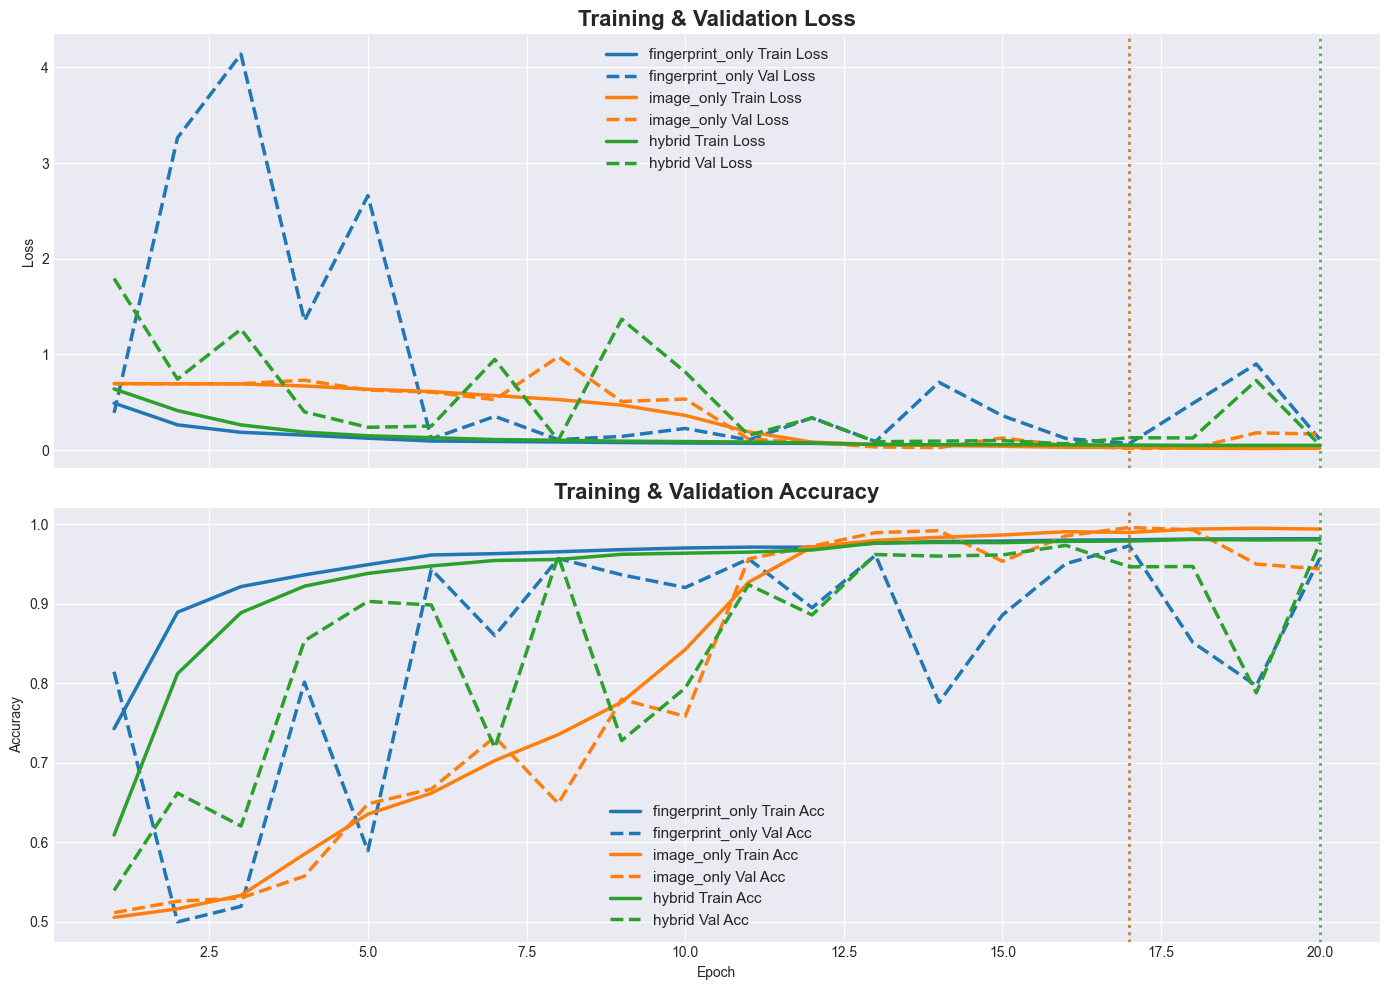

In [ ]:
plot_model_comparison(history)

In [ ]:
@torch.no_grad()
def per_class_confidence(config, dataloader, mode="hybrid", name=""):
    config['model'].eval()
    real_probs = []
    fake_probs = []

    for images, labels in tqdm(dataloader, desc=f"Confidence {name}"):
        images = images.to(config['device'])
        fingerprints = preprocess_batch(images, config, num_patches=192, mode=mode)
        outputs = config['model'](fingerprints)
        probs = torch.sigmoid(outputs)

        for p, label in zip(probs, labels):
            if label.item() == 0:
                real_probs.append(p.item())
            else:
                fake_probs.append(p.item())

    print(f"\n{name} Analysis:")
    print(f"  Real images  → mean prob = {np.mean(real_probs):.4f}")
    print(f"  Fake images  → mean prob = {np.mean(fake_probs):.4f}")
    print(f"  Model predicts 'fake' on {100 * sum(np.array(fake_probs) > 0.5) / len(fake_probs):.1f}% of fake samples")

In [ ]:
_, _, test_loader = define_dataloaders(
    train_size=None,
    val_size=2000,
    test_size=10000,
    samples_per_epoch=100000
)

# Run confidence analysis for all three models
for mode in ["fingerprint_only", "image_only", "hybrid"]:
    config = model_config(mode)
    per_class_confidence(config, test_loader, mode=mode, name=mode.upper())

Confidence FINGERPRINT_ONLY: 100%|██████████| 157/157 [01:06<00:00,  2.35it/s]



FINGERPRINT_ONLY Analysis:
  Real images  → mean prob = 0.5187
  Fake images  → mean prob = 0.5187
  Model predicts 'fake' on 100.0% of fake samples


Confidence IMAGE_ONLY: 100%|██████████| 157/157 [00:57<00:00,  2.75it/s]



IMAGE_ONLY Analysis:
  Real images  → mean prob = 0.5152
  Fake images  → mean prob = 0.5152
  Model predicts 'fake' on 100.0% of fake samples


Confidence HYBRID: 100%|██████████| 157/157 [01:02<00:00,  2.53it/s]


HYBRID Analysis:
  Real images  → mean prob = 0.4636
  Fake images  → mean prob = 0.4636
  Model predicts 'fake' on 0.0% of fake samples


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_epochs_across_models(model_types=None, num_runs=3, test_size=5000):
    """
    Evaluates every saved epoch for each model type.
    Runs the test set 3 times per epoch and averages the results.
    Plots Test Accuracy vs Epoch for all models.
    """
    if model_types is None:
        model_types = ['fingerprint_only', 'image_only', 'hybrid']

    results = {model_type: {'test_acc': [], 'test_loss': []} for model_type in model_types}

    print("Starting epoch-wise evaluation (3 runs per epoch)...\n")

    for model_type in model_types:
        print(f"\n=== Evaluating {model_type.upper()} ===")

        for epoch in range(1, 21):   # assuming you have epochs 1 to 20
            model_path = f"./models/{model_type}/epoch_{epoch}.pth"

            run_accs = []
            run_losses = []

            for run in range(num_runs):
                # Fresh test loader with different random seed each run
                torch.manual_seed(run)
                _, _, test_loader = define_dataloaders(
                    train_size=None,
                    val_size=2000,
                    test_size=test_size,
                    samples_per_epoch=test_size   # use full small test set
                )

                config = model_config(mode=model_type)

                # Load the specific epoch's weights
                ckpt = torch.load(model_path, map_location=config['device'])
                config['model'].load_state_dict(ckpt['model'])
                if config['extractor'] is not None and ckpt.get('extractor') is not None:
                    config['extractor'].load_state_dict(ckpt['extractor'])

                # Run test
                test_loss, test_acc = test(test_loader, config, mode=model_type)

                run_accs.append(test_acc)
                run_losses.append(test_loss)

            # Average the 3 runs
            avg_acc = np.mean(run_accs)
            avg_loss = np.mean(run_losses)

            results[model_type]['test_acc'].append(avg_acc)
            results[model_type]['test_loss'].append(avg_loss)

            print(f"  Epoch {epoch:2d} → Avg Test Acc: {avg_acc:.4f} | Avg Test Loss: {avg_loss:.4f}")

    # === Plot all models together ===
    plt.figure(figsize=(12, 7))
    epochs = range(1, 21)

    for model_type in model_types:
        plt.plot(epochs, results[model_type]['test_acc'],
                 label=model_type.replace('_', ' ').title(),
                 marker='o', linewidth=2.5)

    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Test Accuracy', fontsize=14)
    plt.title('Test Accuracy vs Epoch (Averaged over 3 runs per epoch)', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(0.4, 1.0)   # adjust if needed
    plt.xticks(epochs)
    plt.tight_layout()
    plt.show()

    return results

Starting epoch-wise evaluation (3 runs per epoch)...


=== Evaluating FINGERPRINT_ONLY ===
Running final test on held-out test set for FINGERPRINT_ONLY...


Testing: 100%|██████████| 32/32 [00:16<00:00,  1.95it/s]


FINAL TEST → Loss: 2.5215 | Accuracy: 0.4515

Running final test on held-out test set for FINGERPRINT_ONLY...


Testing: 100%|██████████| 32/32 [00:12<00:00,  2.51it/s]


FINAL TEST → Loss: 3.4313 | Accuracy: 0.4940

Running final test on held-out test set for FINGERPRINT_ONLY...


...

FINAL TEST → Loss: 2.6509 | Accuracy: 0.6055

Running final test on held-out test set for HYBRID...


Testing: 100%|██████████| 32/32 [00:14<00:00,  2.28it/s]


FINAL TEST → Loss: 9.2656 | Accuracy: 0.5165

Running final test on held-out test set for HYBRID...


Testing: 100%|██████████| 32/32 [00:12<00:00,  2.60it/s]

FINAL TEST → Loss: 12.7287 | Accuracy: 0.4930

  Epoch 20 → Avg Test Acc: 0.5383 | Avg Test Loss: 8.2150


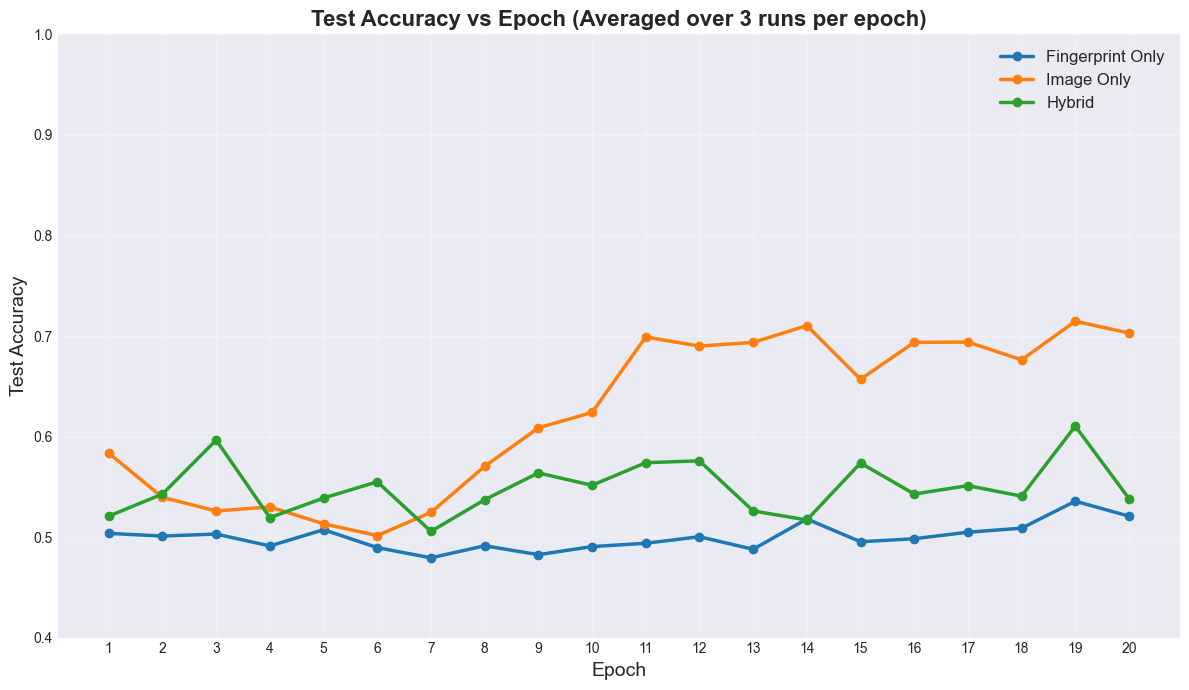

In [ ]:
epoch_results = evaluate_epochs_across_models(
    model_types=['fingerprint_only', 'image_only', 'hybrid'],
    num_runs=3,           # you can change to 5 if you want more stable averages
    test_size=2000        # you can make this smaller (e.g. 2000) for faster runs
)

##Achieving the original goal

# Conclusion